In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [17]:
# 1. Missing Values Check
print("Missing values in each column:\n", df.isnull().sum())

df.drop_duplicates(inplace=True)

cols_to_drop = ['Over18', 'StandardHours', 'EmployeeCount', 'EmployeeNumber']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

print("\nCleaned Data Shape:", df.shape)

Missing values in each column:
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInC

/tmp/ipykernel_515/137144784.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Attrition', data=df, palette='Set2')


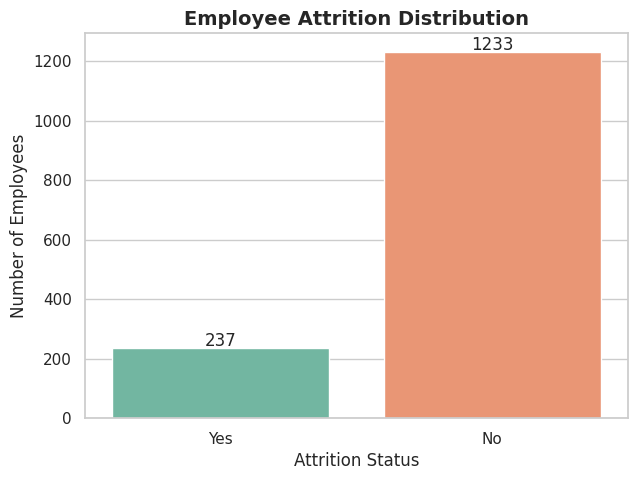

In [18]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Attrition', data=df, palette='Set2')
plt.title('Employee Attrition Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Status', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

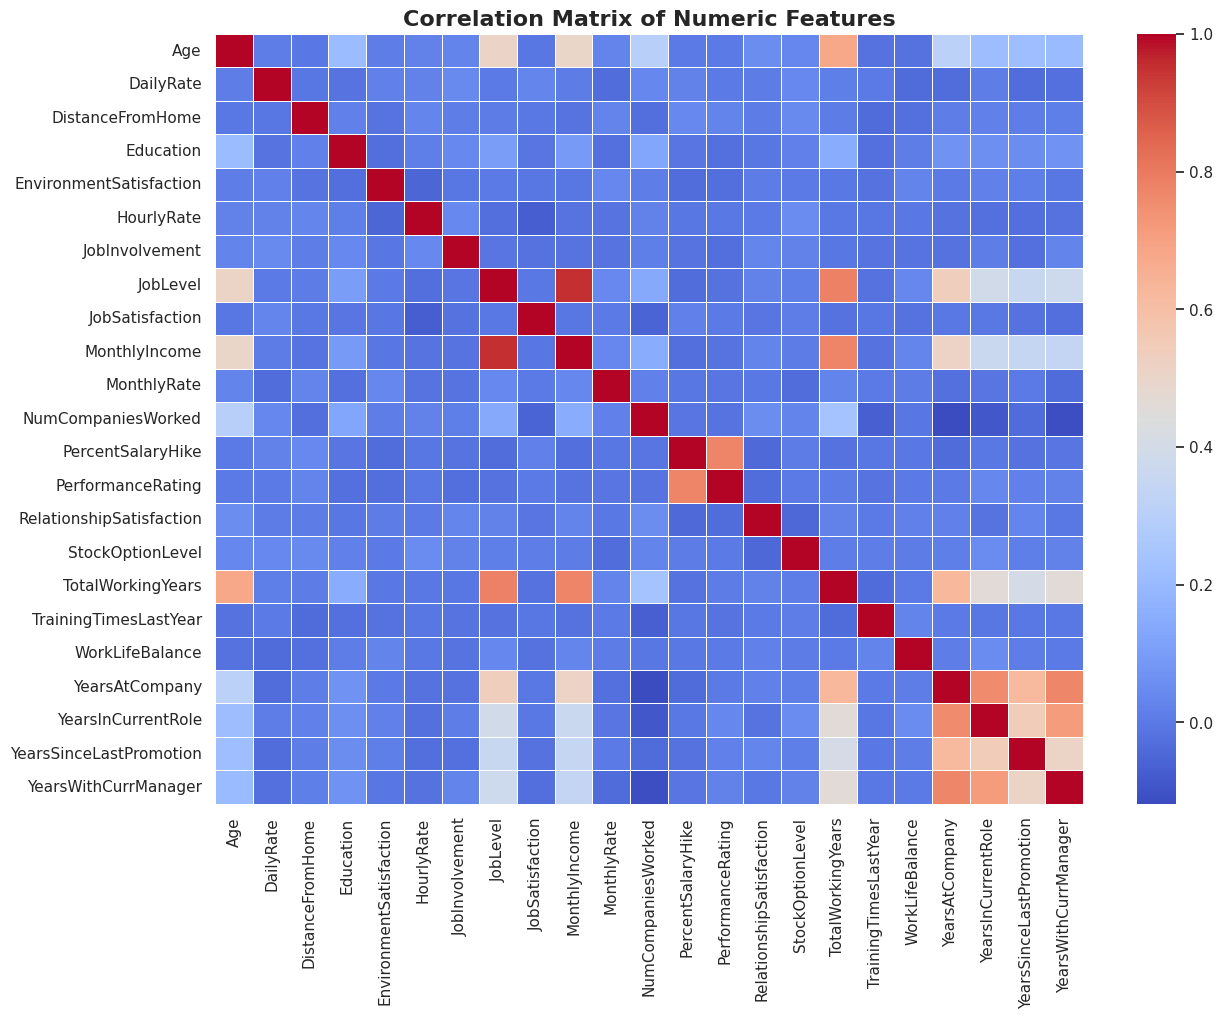

In [19]:
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features', fontsize=16, fontweight='bold')
plt.show()

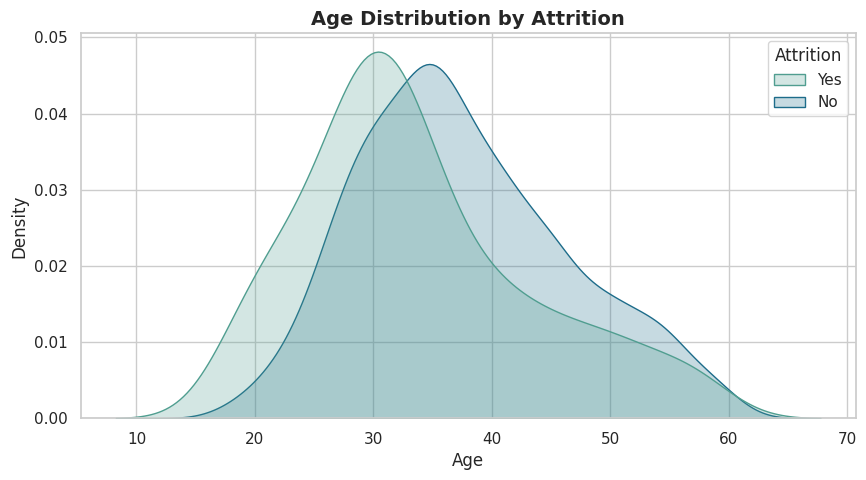

In [20]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x="Age", hue="Attrition", fill=True, palette="crest", common_norm=False)
plt.title('Age Distribution by Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.show()

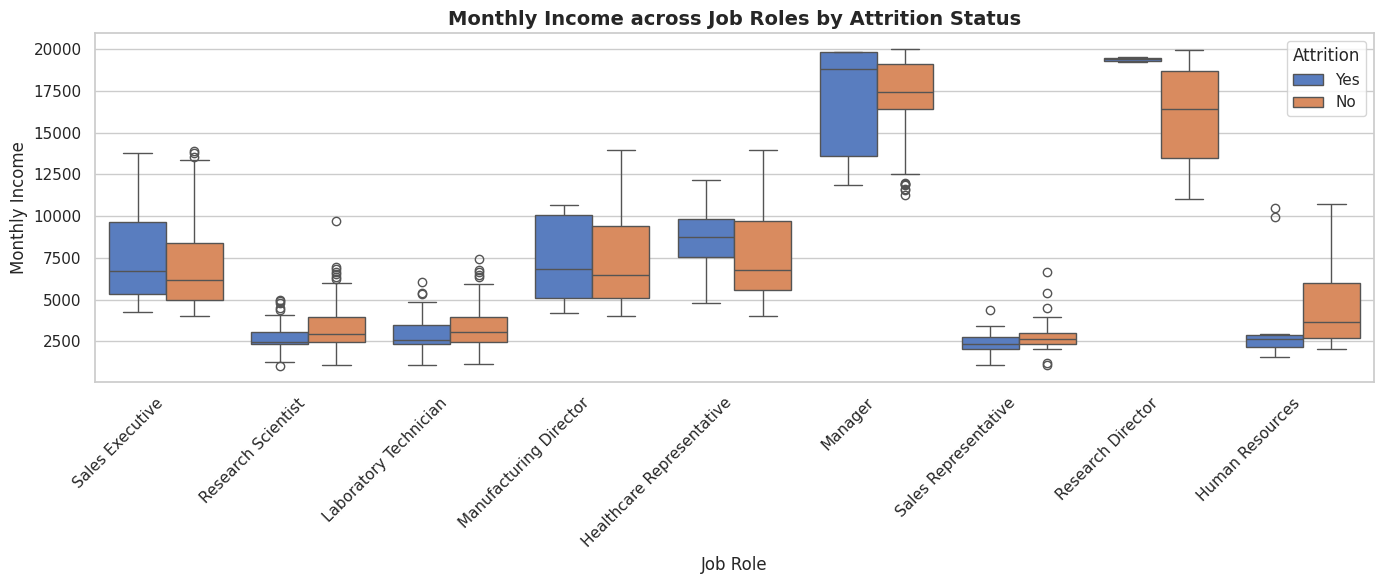

In [21]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='JobRole', y='MonthlyIncome', hue='Attrition', data=df, palette='muted')
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Income across Job Roles by Attrition Status', fontsize=14, fontweight='bold')
plt.xlabel('Job Role', fontsize=12)
plt.ylabel('Monthly Income', fontsize=12)
plt.tight_layout()
plt.show()

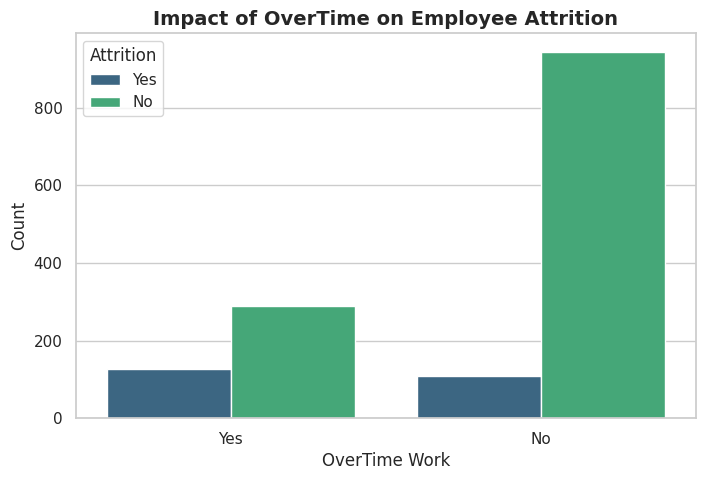

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(x='OverTime', hue='Attrition', data=df, palette='viridis')
plt.title('Impact of OverTime on Employee Attrition', fontsize=14, fontweight='bold')
plt.xlabel('OverTime Work', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()